Mapping the developmental trajectory of human astrocytes reveals divergence in glioblastoma
* Data: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE276176

# Import packages

In [1]:
import os
import re
import requests
import pandas as pd
import datetime

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import gseapy as gp

# Download data

In [2]:
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE276nnn/GSE276176/suppl/GSE276176_GBM_feature_counts.xlsx"
# https://ftp.ncbi.nlm.nih.gov/geo/series/GSE276nnn/GSE276176/suppl contains all the supplimentary data
# GSE276176_GBM_feature_counts.xlsx is the file for tumor vs margin astrocytes

direct_input = 'input/s41556-024-01583-9'
direct_output = 'output/s41556-024-01583-9'

for direct in [direct_input, direct_output]:
    os.makedirs(direct, exist_ok=True)

In [3]:
file_path = os.path.join(direct_input, "GSE276176_GBM_feature_counts.xlsx")

r = requests.get(url)
r.raise_for_status()


with open(file_path, "wb") as f:
    f.write(r.content)

In [4]:
df = pd.read_excel(file_path)
df = df.rename(columns={df.columns[0]: "Gene"}) # Original col title is Geneid and that messes up some later codes

df.head()

,Gene,GBM10M_RNA,GBM10T_RNA,GBM11M_RNA,GBM11T_RNA,GBM12M_RNA,GBM12T_RNA,GBM15M_RNA,GBM15T_RNA,GBM18T_RNA,...,GBM32M_RNA,GBM32T_RNA,GBM33M_RNA,GBM33T_RNA,GBM37M_RNA,GBM37T_RNA,GBM38M_RNA,GBM38T_RNA,GBM40M_RNA,GBM40T_RNA
0,DDX11L1,0,0,0,1,0,0,0,1,0,...,0,2,7,2,0,0,0,0,0,0
1,WASH7P,34,124,25,18,34,20,42,70,109,...,114,119,94,130,57,92,73,60,142,215
2,MIR6859-3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,MIR6859-2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,MIR6859-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.columns

Index(['Gene', 'GBM10M_RNA', 'GBM10T_RNA', 'GBM11M_RNA', 'GBM11T_RNA',
       'GBM12M_RNA', 'GBM12T_RNA', 'GBM15M_RNA', 'GBM15T_RNA', 'GBM18T_RNA',
       'GBM20M_RNA', 'GBM20T_RNA', 'GBM21M_RNA', 'GBM21T_RNA', 'GBM22M_RNA',
       'GBM22T_RNA', 'GBM24M_RNA', 'GBM24T_RNA', 'GBM25M_RNA', 'GBM25T_RNA',
       'GBM28T_RNA', 'GBM30M_RNA', 'GBM30T_RNA', 'GBM31M_RNA', 'GBM31T_RNA',
       'GBM32M_RNA', 'GBM32T_RNA', 'GBM33M_RNA', 'GBM33T_RNA', 'GBM37M_RNA',
       'GBM37T_RNA', 'GBM38M_RNA', 'GBM38T_RNA', 'GBM40M_RNA', 'GBM40T_RNA'],
      dtype='object')

In [6]:
df['Gene'].head()

0      DDX11L1
1       WASH7P
2    MIR6859-3
3    MIR6859-2
4    MIR6859-1
Name: Gene, dtype: object

# df gene col cleaning

In [7]:
# I later found out that some gene names becomes timestamp after some processing and it turned out that the original data has problematic rows whose gene names are timestamps. I will remove those rows

df['Gene'].map(type).value_counts()

Gene
<class 'str'>                  26457
<class 'datetime.datetime'>       28
Name: count, dtype: int64

In [8]:
print(f'Before removing timestamp rows, the count table has {df.shape[0]} rows')

df = df[~df['Gene'].map(lambda x: isinstance(x, datetime.datetime))] # Remove rows with gene name as timestamp

print(f'After removing timestamp rows, the count table has {df.shape[0]} rows')

Before removing timestamp rows, the count table has 26485 rows
After removing timestamp rows, the count table has 26457 rows


# Build sample groups

In [9]:
sample_list = [
    col for col in df.columns
    if col.endswith("M_RNA") or col.endswith("T_RNA")
]

sample_list

['GBM10M_RNA',
 'GBM10T_RNA',
 'GBM11M_RNA',
 'GBM11T_RNA',
 'GBM12M_RNA',
 'GBM12T_RNA',
 'GBM15M_RNA',
 'GBM15T_RNA',
 'GBM18T_RNA',
 'GBM20M_RNA',
 'GBM20T_RNA',
 'GBM21M_RNA',
 'GBM21T_RNA',
 'GBM22M_RNA',
 'GBM22T_RNA',
 'GBM24M_RNA',
 'GBM24T_RNA',
 'GBM25M_RNA',
 'GBM25T_RNA',
 'GBM28T_RNA',
 'GBM30M_RNA',
 'GBM30T_RNA',
 'GBM31M_RNA',
 'GBM31T_RNA',
 'GBM32M_RNA',
 'GBM32T_RNA',
 'GBM33M_RNA',
 'GBM33T_RNA',
 'GBM37M_RNA',
 'GBM37T_RNA',
 'GBM38M_RNA',
 'GBM38T_RNA',
 'GBM40M_RNA',
 'GBM40T_RNA']

In [10]:
metadata = pd.DataFrame(index=sample_list)

metadata["condition"] = [
    "margin" if s.endswith("M_RNA") else "tumor"
    for s in sample_list
]

metadata["patient"] = [
    re.search(r"GBM(\d+)", s).group(1)
    for s in sample_list
]

metadata

,condition,patient
GBM10M_RNA,margin,10
GBM10T_RNA,tumor,10
GBM11M_RNA,margin,11
GBM11T_RNA,tumor,11
GBM12M_RNA,margin,12
GBM12T_RNA,tumor,12
GBM15M_RNA,margin,15
GBM15T_RNA,tumor,15
GBM18T_RNA,tumor,18
GBM20M_RNA,margin,20


In [11]:
metadata["condition"].value_counts()
metadata["patient"].value_counts().sort_index()

patient
10    2
11    2
12    2
15    2
18    1
20    2
21    2
22    2
24    2
25    2
28    1
30    2
31    2
32    2
33    2
37    2
38    2
40    2
Name: count, dtype: int64

In [12]:
# For paired patient design, remove patients with only one sample
paired_patients = metadata["patient"].value_counts()
paired_patients = paired_patients[paired_patients == 2].index

metadata = metadata[metadata["patient"].isin(paired_patients)]
metadata # All patients in this df should have 2 samples

,condition,patient
GBM10M_RNA,margin,10
GBM10T_RNA,tumor,10
GBM11M_RNA,margin,11
GBM11T_RNA,tumor,11
GBM12M_RNA,margin,12
GBM12T_RNA,tumor,12
GBM15M_RNA,margin,15
GBM15T_RNA,tumor,15
GBM20M_RNA,margin,20
GBM20T_RNA,tumor,20


# Create count matrix

In [13]:
counts = df[["Gene"] + metadata.index.tolist()].copy() # Only used data from paired patient
counts = counts.set_index("Gene")
counts = counts.astype(int)

counts.head() # Number of col should agree with the metadata's row count

,GBM10M_RNA,GBM10T_RNA,GBM11M_RNA,GBM11T_RNA,GBM12M_RNA,GBM12T_RNA,GBM15M_RNA,GBM15T_RNA,GBM20M_RNA,GBM20T_RNA,...,GBM32M_RNA,GBM32T_RNA,GBM33M_RNA,GBM33T_RNA,GBM37M_RNA,GBM37T_RNA,GBM38M_RNA,GBM38T_RNA,GBM40M_RNA,GBM40T_RNA
Gene,,,,,,,,,,,,,,,,,,,,,
DDX11L1,0,0,0,1,0,0,0,1,0,0,...,0,2,7,2,0,0,0,0,0,0
WASH7P,34,124,25,18,34,20,42,70,58,55,...,114,119,94,130,57,92,73,60,142,215
MIR6859-3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR6859-2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR6859-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## counts df filtering

In [14]:
print(f'Before removing NaN rows, the count table has {counts.shape[0]} rows')

counts = counts.dropna() # Remove rows with NaN values, aka missing values. DEseq2 can't handle NaN values

print(f'After removing NaN rows, the count table has {counts.shape[0]} rows')

Before removing NaN rows, the count table has 26457 rows
After removing NaN rows, the count table has 26457 rows


In [15]:
print(f'Before merging duplicated gene rows, the count table has {counts.shape[0]} rows')

counts = counts.groupby('Gene').sum() # Sometimes GEO tables contain duplicated gene symbols. This line merges duplicated gene rows

print(f'After merging duplicated gene rows, the count table has {counts.shape[0]} rows')

Before merging duplicated gene rows, the count table has 26457 rows
After merging duplicated gene rows, the count table has 26457 rows


In [16]:
print(f'Before removing almost never expressed genes, the count table has {counts.shape[0]} rows')

keep = counts.sum(axis=1) >= 10 # Remove genes with extremely low overall counts. Lower than 10 total counts across all sample is regarded as almost never expressed genes here
counts = counts.loc[keep, :]

print(f'After removing almost never expressed genes, the count table has {counts.shape[0]} rows')

Before removing almost never expressed genes, the count table has 26457 rows
After removing almost never expressed genes, the count table has 21332 rows


In [17]:
count_cols = counts.columns[1:]   # everything except Gene col
counts[count_cols] = counts[count_cols].astype(int) # Converts values to integers because DEseq2 expect integers

counts.head()

,GBM10M_RNA,GBM10T_RNA,GBM11M_RNA,GBM11T_RNA,GBM12M_RNA,GBM12T_RNA,GBM15M_RNA,GBM15T_RNA,GBM20M_RNA,GBM20T_RNA,...,GBM32M_RNA,GBM32T_RNA,GBM33M_RNA,GBM33T_RNA,GBM37M_RNA,GBM37T_RNA,GBM38M_RNA,GBM38T_RNA,GBM40M_RNA,GBM40T_RNA
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,245,594,154,11,87,131,222,275,70,184,...,45,135,277,158,98,309,177,252,33,65
A1BG-AS1,3,19,0,0,2,1,12,14,9,20,...,0,24,23,9,3,34,16,27,0,4
A1CF,0,1,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
A2M,840,56,1503,45671,772,3665,3928,3587,11097,26160,...,1719,4423,3790,6406,3785,35657,5317,1376,1481,301
A2M-AS1,0,4,0,7,6,41,2,1,2,8,...,2,13,32,0,2,25,19,0,0,0


In [18]:
len(counts.columns)

32

# Run differential expression

In [19]:
# DESeq2 expects samples x genes
counts_transposed = counts.T # Transpose the count matrix
counts_transposed.iloc[:, :5] # This displays the 1st 5 col with the full rows as a preview. Now the counts has been transposed so using counts_t.head() isn't appropriate anymore since it has tons of col

# DESeq2 expects the input counts df to have the 1st col (can have or have no col title) to be sample names and each other col to be a gene

Gene,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1
GBM10M_RNA,245,3,0,840,0
GBM10T_RNA,594,19,1,56,4
GBM11M_RNA,154,0,0,1503,0
GBM11T_RNA,11,0,0,45671,7
GBM12M_RNA,87,2,0,772,6
GBM12T_RNA,131,1,0,3665,41
GBM15M_RNA,222,12,0,3928,2
GBM15T_RNA,275,14,1,3587,1
GBM20M_RNA,70,9,1,11097,2
GBM20T_RNA,184,20,0,26160,8


In [20]:
counts_transposed.index.equals(metadata.index)

True

In [21]:
# Make sure metadata rows are in the exact same order as counts_transposed rows
metadata = metadata.loc[counts_transposed.index]

# Make categorical factors explicit
metadata["patient"] = metadata["patient"].astype("category")
metadata["condition"] = metadata["condition"].astype("category")

inference = DefaultInference(
    n_cpus = 8 # 1 to avoid multiprocessing error, which is usually caused by one of the obj cannot be pickled
)
dds = DeseqDataSet( # Create DESeq2 analysis obj
    counts=counts_transposed,
    metadata=metadata,
    design="~ patient + condition", # This means after taking the patient variance into account, investigate the difference between different conditions
    # I later added "patient"
    # "condition" is the col title for the col that labels what each sample is (normal or tumor) in metadata
    refit_cooks = True, # True to refit Cooks outliers, which is advised
    inference = inference
)

if counts_transposed.index.equals(metadata.index): # The row names of the input metadata df must match the row names of the input counts df

    dds.deseq2() # Fit the dispersions and LFC to the model
    # 1. Normalizes for library size
    # 2. Estimates dispersion/noise for each gene
    # 3. Fits negative binomial model because RNA-seq count data are not normally distributed
    # 4. Prepares the object for statistical testing

Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 9.29 seconds.

Fitting dispersion trend curve...
... done in 0.52 seconds.

Fitting MAP dispersions...
... done in 8.99 seconds.

Fitting LFCs...
... done in 14.48 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 0 outlier genes.



In [22]:
print(dds) # This is a AnnData class obj

AnnData object with n_obs × n_vars = 32 × 21332
    obs: 'condition', 'patient', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'


## QC on model fitting

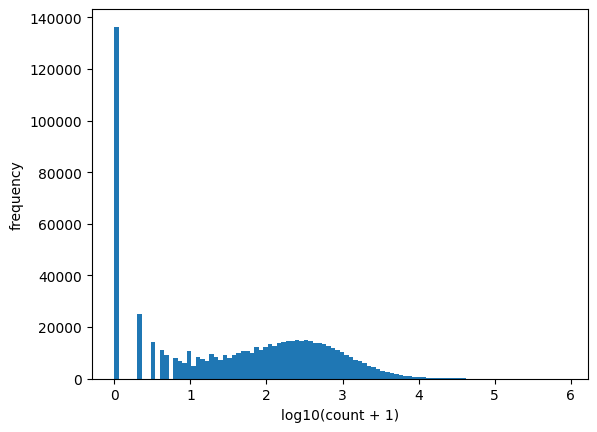

In [23]:
log_counts = np.log10(counts_transposed + 1)

plt.hist(log_counts.values.flatten(), bins=100)
plt.xlabel("log10(count + 1)")
plt.ylabel("frequency")
plt.show() # RNA-seq distribution should be highly skewed

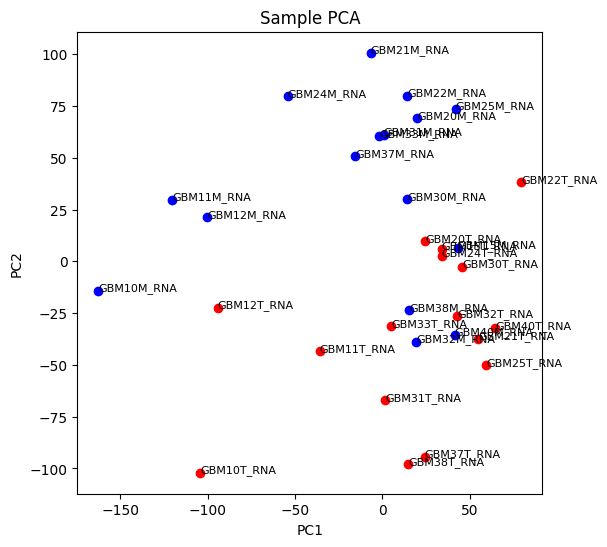

In [24]:
X = np.log2(counts_transposed + 1)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,6))

for i, sample in enumerate(counts_transposed.index):

    condition = metadata.loc[sample, "condition"]

    color = "red" if condition == "tumor" else "blue"

    plt.scatter(
        pcs[i,0],
        pcs[i,1],
        color=color
    )

    plt.text(
        pcs[i,0],
        pcs[i,1],
        sample,
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Sample PCA")
plt.show() # Similar samples should be clustered together

# For this set of samples, you should see less of a separation since these astrocytes are from margin vs. tumor, not healthy vs. tumor
# Also patient effects is more dominant that condition effect since you can see some patients' margin and tumor samples are closer than cross-patient samples

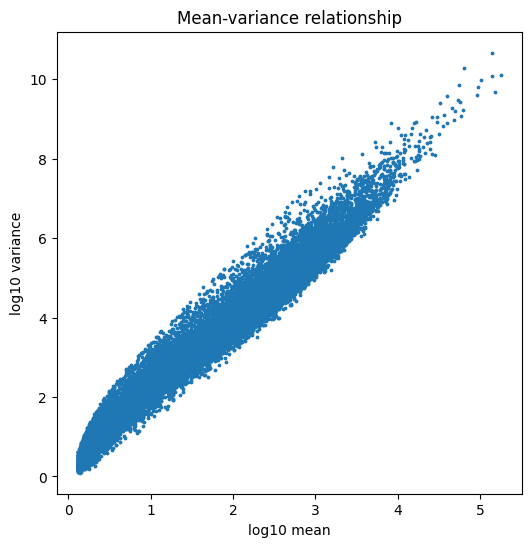

In [25]:
gene_means = counts_transposed.mean(axis=0)
gene_vars = counts_transposed.var(axis=0)

plt.figure(figsize=(6,6))

plt.scatter(
    np.log10(gene_means + 1),
    np.log10(gene_vars + 1),
    s=3
)

plt.xlabel("log10 mean")
plt.ylabel("log10 variance")
plt.title("Mean-variance relationship")
plt.show() # Because it's negative binomial, variance should increase with mean

# Extract results

In [26]:
stat_res = DeseqStats(
    dds,
    contrast=["condition", "tumor", "margin"], # Compare tumor against normal using the metadata column "condition" -> condition: tumor vs normal
    inference = inference
)

In [27]:
stat_res.summary() # Run Wald tests to compute p-values. Null hypothesis: for each gene, tumor expression is equal to normal expression

Running Wald tests...


Log2 fold change & Wald test p-value: condition tumor vs margin
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                          
A1BG        195.267112        0.642665  0.330478  1.944653  0.051817  0.116279
A1BG-AS1     12.956565        1.458784  0.557932  2.614625  0.008933  0.029055
A1CF          0.522430       -0.315172  3.062959 -0.102898  0.918044       NaN
A2M       12779.637568        0.424373  0.431182  0.984209  0.325013  0.470132
A2M-AS1      10.893988       -0.156304  0.845922 -0.184773  0.853407  0.910267
...                ...             ...       ...       ...       ...       ...
ZYG11A        0.693841        0.601895  3.047405  0.197511  0.843428       NaN
ZYG11B      358.036547       -0.669037  0.225785 -2.963165  0.003045  0.012281
ZYX        2304.180853        1.055880  0.256700  4.113290  0.000039  0.000350
ZZEF1       190.068565        0.117115  0.250799  0.466969  0.64052

... done in 2.28 seconds.



## LFC shrinkage
Raw log2 fold changes can become unrealistically huge for noisy low-count genes

Without shrinkage, DEG ranking becomes dominated by low-count noisy genes instead of robust biology.

In [28]:
print(dds.obsm['design_matrix'].columns) # Output will be the coeff for LFC shrinkage

Index(['Intercept', 'patient[T.11]', 'patient[T.12]', 'patient[T.15]',
       'patient[T.20]', 'patient[T.21]', 'patient[T.22]', 'patient[T.24]',
       'patient[T.25]', 'patient[T.30]', 'patient[T.31]', 'patient[T.32]',
       'patient[T.33]', 'patient[T.37]', 'patient[T.38]', 'patient[T.40]',
       'condition[T.tumor]'],
      dtype='object')


In [29]:
stat_res.lfc_shrink(
    coeff='condition[T.tumor]' # See the output of print(dds.obsm['design_matrix'].columns)
)

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: condition[T.tumor]
              baseMean  log2FoldChange      lfcSE      stat    pvalue  \
Gene                                                                    
A1BG        195.267112        0.533249   0.338802  1.944653  0.051817   
A1BG-AS1     12.956565        1.087289   0.663027  2.614625  0.008933   
A1CF          0.522430        0.004927   0.799827 -0.102898  0.918044   
A2M       12779.637568        0.290161   0.485474  0.984209  0.325013   
A2M-AS1      10.893988       -0.038163   0.399255 -0.184773  0.853407   
...                ...             ...        ...       ...       ...   
ZYG11A        0.693841        0.034296  10.095273  0.197511  0.843428   
ZYG11B      358.036547       -0.616695   0.243921 -2.963165  0.003045   
ZYX        2304.180853        0.983827   0.272593  4.113290  0.000039   
ZZEF1       190.068565        0.102607   0.243334  0.466969  0.640522   
ZZZ3        253.638300       -0.940618   0.297807 -3.696116 

... done in 16.75 seconds.



In [30]:
result_df = stat_res.results_df # Extract the final result table into a df
result_df.head()

# baseMean: average normalized expression. Higher means gene is strongly expressed overall
# log2FoldChange: if positive, expression is higher in tumor; if negative, expression is higher in normal
# lfcSE: Uncertainty of fold change estimate. Smaller is more reliable
# stat: Wald statistic. Higher means stronger evidence
# pvalue: raw significance. Need to be adjusted since you have tons of genes
# padj: FDR-adjusted p-value. Typical cutoff at 0.05

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
A1BG,195.267112,0.533249,0.338802,1.944653,0.051817,0.116279
A1BG-AS1,12.956565,1.087289,0.663027,2.614625,0.008933,0.029055
A1CF,0.522430,0.004927,0.799827,-0.102898,0.918044,NaN
A2M,12779.637568,0.290161,0.485474,0.984209,0.325013,0.470132
A2M-AS1,10.893988,-0.038163,0.399255,-0.184773,0.853407,0.910267


# Result analysis

## Filter significant DEG

In [31]:
signif_df = result_df[
    (result_df["padj"] < 0.05) & # Statistically significant
    (result_df["log2FoldChange"].abs() > 1) # Biologically meaningful in effect size. This filters for gene expressions that are 2 times higher or lower in tumor. You can filter for higher differential expression
].copy()

signif_df = signif_df.sort_values('padj')

signif_df.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
MOBP,2465.833186,-7.282556,0.650167,-14.034578,9.576417e-45,1.686311e-40
NKX6-2,478.579978,-5.756251,0.467241,-13.834162,1.585735e-43,1.396160e-39
MOG,3668.115115,-5.873214,0.498815,-13.202612,8.474447e-40,4.974218e-36
MBP,138198.838320,-5.894130,0.567673,-13.130580,2.199654e-39,9.683426e-36
HAPLN2,1932.567056,-6.162405,0.587711,-13.032968,7.945540e-39,2.798260e-35


In [32]:
signif_df.to_csv(f"{direct_output}/GBM_tumor_vs_margin_astrocytes_significant_DEGs.csv")

## Separate up/down genes

In [33]:
up = signif_df[signif_df["log2FoldChange"] > 1].sort_values(
    "log2FoldChange",
    ascending=False
)

down = signif_df[signif_df["log2FoldChange"] < -1].sort_values(
    "log2FoldChange"
)

up.to_csv(f"{direct_output}/GBM_tumor_vs_margin_up_in_tumor.csv")
down.to_csv(f"{direct_output}/GBM_tumor_vs_margin_down_in_tumor.csv")

## Volcano plot

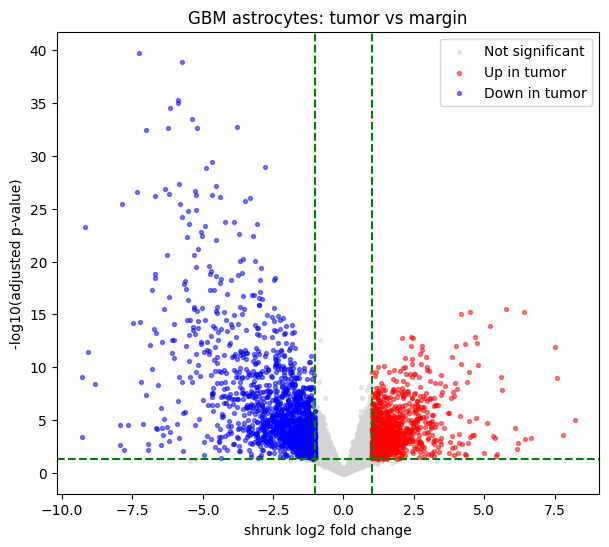

In [34]:
plot_df = result_df.dropna(subset=["padj", "log2FoldChange"]).copy()

# Remove genes collapsed to near-zero LFC after LFC shrinkage for plotting only
plot_df = plot_df[plot_df["log2FoldChange"].abs() > 0.01].copy()
# This just make the volcano plot look cleaner but those gotten-rid-of genes can still be biologically/statistically valid

# Avoid infinite values if padj = 0
plot_df["padj_plot"] = plot_df["padj"].replace(0, 1e-300)
plot_df["neglog10_padj"] = -np.log10(plot_df["padj_plot"])

plot_df["direction"] = "Not significant"

plot_df.loc[
    (plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] > 1),
    "direction"
] = "Up in tumor"

plot_df.loc[
    (plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] < -1),
    "direction"
] = "Down in tumor"

plt.figure(figsize=(7, 6))

colors = {
    "Not significant": "lightgray",
    "Up in tumor": "red",
    "Down in tumor": "blue"
}

for direction, color in colors.items():
    sub = plot_df[plot_df["direction"] == direction]

    plt.scatter(
        sub["log2FoldChange"],
        sub["neglog10_padj"],
        s=8,
        alpha=0.5,
        color=color,
        label=direction
    )

for x in [1, -1]:
    plt.axvline(x, linestyle="--", color="green")

plt.axhline(-np.log10(0.05), linestyle="--", color="green")

plt.xlabel("shrunk log2 fold change")
plt.ylabel("-log10(adjusted p-value)")
plt.title("GBM astrocytes: tumor vs margin")

plt.legend()
plt.show()

In [35]:
# If gene names are in the index
plot_df["gene"] = plot_df.index

fig = px.scatter(
    plot_df,
    x="log2FoldChange",
    y="neglog10_padj",
    color="direction",
    color_discrete_map={
        "Up in tumor": "red",
        "Down in tumor": "blue",
        "Not significant": "lightgray"
    },
    hover_name="gene",
    hover_data={
        "log2FoldChange": ":.3f",
        "padj": ":.3e",
        "baseMean": ":.2f",
        "neglog10_padj": False,
        "padj_plot": False,
        "direction": True
    },
    title="GBM astrocytes: tumor vs margin",
    labels={
        "log2FoldChange": "shrunk log2 fold change",
        "neglog10_padj": "-log10(adjusted p-value)"
    },
    opacity=0.5,
    render_mode="webgl"
)

for x in [1, -1]:
    fig.add_vline(x=x, line_dash="dash", line_color="green")

fig.add_hline(
    y=-np.log10(0.05),
    line_dash="dash",
    line_color="green"
)

fig.update_traces(marker=dict(size=5))

fig.write_html(
    f"{direct_output}/GBM_tumor_vs_margin_interactive_volcano_plot.html",
    include_plotlyjs="cdn"
)

fig.show()

## Pick candidate genes
This is more stringent filtering

In [36]:
candidates = signif_df[
    (signif_df["padj"] < 0.01) &
    (signif_df["log2FoldChange"].abs() > 2) &
    (signif_df["baseMean"] > 50)
    ].copy()

candidates = candidates.sort_values(
    ["padj", "log2FoldChange"],
    ascending=[True, False]
)

candidates.to_csv(
    f"{direct_output}/GBM_tumor_vs_margin_candidate_genes_for_downstream_study.csv"
)

## Pathway enrichment

In [37]:
up_genes = up.index.tolist()
down_genes = down.index.tolist()

enr_up = gp.enrichr(
    gene_list=up_genes,
    gene_sets=[
        "GO_Biological_Process_2023",
        "KEGG_2021_Human",
        "MSigDB_Hallmark_2020"
    ],
    organism="homo sapiens"
)

enr_down = gp.enrichr(
    gene_list=down_genes,
    gene_sets=[
        "GO_Biological_Process_2023",
        "KEGG_2021_Human",
        "MSigDB_Hallmark_2020"
    ],
    organism="homo sapiens"
)

enr_up.results.to_csv(
    f"{direct_output}/enrichment_up_in_tumor_vs_margin.csv",
    index=False
)

enr_down.results.to_csv(
    f"{direct_output}/enrichment_down_in_tumor_vs_margin.csv",
    index=False
)

## Make a ranked gene list

In [38]:
ranked = result_df.dropna(subset=["padj", "log2FoldChange"]).copy()

ranked["score"] = ranked["log2FoldChange"] * (-np.log10(ranked["padj"]))

ranked = ranked.sort_values("score", ascending=False)
ranked.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,score
Gene,,,,,,,
CA9,868.342565,6.422802,0.969355,8.701231,3.283044e-18,6.150120e-16,97.697992
GPRC5A,128.563676,5.759855,0.812522,8.779435,1.642984e-18,3.287648e-16,89.180489
SLN,360.995946,7.505606,1.398808,7.698745,1.374093e-14,1.382652e-12,89.011134
TEAD4,78.173783,5.203079,0.815340,8.318759,8.888880e-17,1.293589e-14,72.261420
ABCC3,643.239206,4.490389,0.640790,8.695848,3.442479e-18,6.380906e-16,68.231996


In [39]:
ranked.to_csv(f"{direct_output}/ranked_genes_GBM_tumor_vs_normal.csv")